In [1]:
# check version number
import imblearn
print(imblearn.__version__)

0.11.0


In [2]:
# In this section, we will develop an intuition for the SMOTE by applying it to an imbalanced binary classification problem.
from collections import Counter
from sklearn.datasets import make_classification
from matplotlib import pyplot
import matplotlib.pyplot as plt
from numpy import where
import pandas as pd
import numpy as np
import os

# define dataset
#df = pd.read_csv("C:\\Users\\olufe\\projects\\Journal\\dataset\\HomeA_unsupervised_sim_combined_shuffled.csv")
#X, y = make_classification(n_samples=10000, n_features=2, n_redundant=0,
#	n_clusters_per_class=1, weights=[0.99], flip_y=0, random_state=1)

In [3]:
# File paths
train_csv_file_path = r"C:\Users\olufe\projects\Journal\dataset\psa_journal_home_A_unsupervise_train.csv"
test_csv_file_path = r"C:\Users\olufe\projects\Journal\dataset\psa_journal_home_A_sim_test.csv"

# Load the training data from the CSV file
train_data = pd.read_csv(train_csv_file_path)

# Load the test data from the CSV file
test_data = pd.read_csv(test_csv_file_path)

# Extract features (X) and target labels (y) from the training data
X_train = train_data.drop(columns=["Label"])  # Replace "target_column_name" with the actual column name for the target variable in the training data
y_train = train_data["Label"]  # Replace "target_column_name" with the actual column name for the target variable in the training data

# Extract features (X) and target labels (y) from the test data
X_test = test_data.drop(columns=["Label"])  # Replace "target_column_name" with the actual column name for the target variable in the test data
y_test = test_data["Label"]  # Replace "target_column_name" with the actual column name for the target variable in the test data

# Print the shape of the DataFrames
print("Shape of X_train:", X_train.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_test:", y_test.shape)


Shape of X_train: (35040, 1380)
Shape of y_train: (35040,)
Shape of X_test: (290, 1380)
Shape of y_test: (290,)


In [5]:
#train_data

In [6]:
test_data

,M0,M1,M2,M3,M4,M5,M6,M7,M8,M9,...,M1371,M1372,M1373,M1374,M1375,M1376,M1377,M1378,M1379,Label
0,285,286,286,286,289,287,429,426,416,416,...,858,1099,937,1036,1065,1020,912,858,788,0
1,680,251,247,249,385,535,527,530,522,424,...,1912,2018,2101,2140,2151,2175,2206,2190,2182,0
2,793,798,829,921,992,1022,918,954,930,993,...,386,379,392,392,384,382,378,380,380,0
3,362,316,288,285,286,289,287,287,288,285,...,833,857,824,817,788,783,808,884,976,1
4,3670,1296,1355,1296,1364,1223,1249,1301,1297,1341,...,492,490,488,479,488,479,472,475,1218,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
285,431,430,439,433,438,430,429,431,430,427,...,427,423,422,440,415,423,423,418,425,0
286,6559,6606,6518,6531,6563,6729,6578,6149,6048,6047,...,3031,3066,3028,3073,3109,3102,3196,3108,3071,1
287,447,379,378,380,377,447,383,375,378,366,...,1802,1966,2066,2093,2123,2139,2141,2154,2152,0
288,987,824,871,833,877,956,854,1086,1072,1048,...,518,536,533,530,529,983,949,934,946,1


In [8]:
#train_data.info()

In [9]:
#test_data.describe

In [13]:
# summarize class distribution
#counter = Counter(y_train)
#print(counter)

# Summarize class distribution for y_train
counter_train = Counter(y_train)
print("Class distribution for y_train:")
print(counter_train)

# Summarize class distribution for y_test
counter_test = Counter(y_test)
print("Class distribution for y_test:")
print(counter_test)

Class distribution for y_train:
Counter({0: 35040})
Class distribution for y_test:
Counter({0: 146, 1: 144})


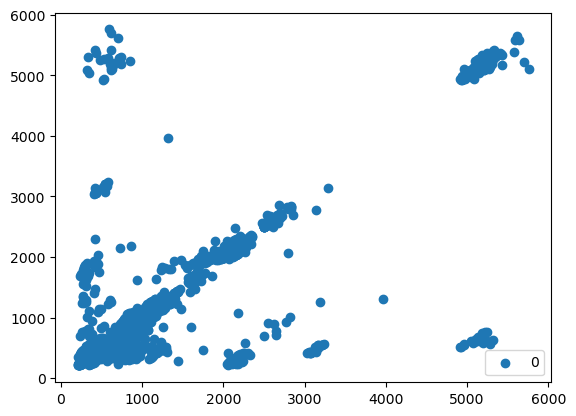

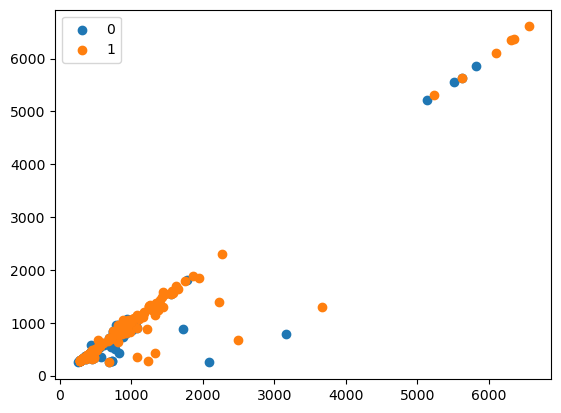

In [15]:
# Plot scatter points for each label in y
#unique_labels = y.unique()
#for label in unique_labels:
#    row_ix = y[y == label].index
#    plt.scatter(X.loc[row_ix, X.columns[0]], X.loc[row_ix, X.columns[1]], label=str(label))
#plt.legend()
#plt.show()

# Plot scatter points for each label in y_train
unique_labels = y_train.unique()
for label in unique_labels:
    row_ix_train = y_train[y_train == label].index
    plt.scatter(X_train.loc[row_ix_train, X_train.columns[0]], X_train.loc[row_ix_train, X_train.columns[1]], label=str(label))
plt.legend()
plt.show()

# Plot scatter points for each label in y_test
unique_labels = y_test.unique()
for label in unique_labels:
    row_ix_test = y_test[y_test == label].index
    plt.scatter(X_test.loc[row_ix_test, X_test.columns[0]], X_test.loc[row_ix_test, X_test.columns[1]], label=str(label))
plt.legend()
plt.show()

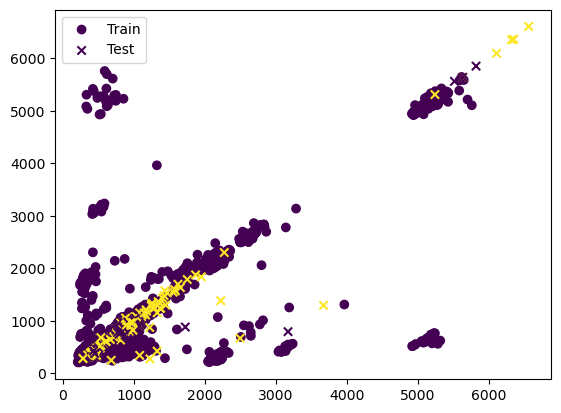

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# File paths
train_csv_file_path = r"C:\Users\olufe\projects\Journal\dataset\psa_journal_home_A_unsupervise_train.csv"
test_csv_file_path = r"C:\Users\olufe\projects\Journal\dataset\psa_journal_home_A_sim_test.csv"

# Load the training data from the CSV file
train_data = pd.read_csv(train_csv_file_path)

# Load the test data from the CSV file
test_data = pd.read_csv(test_csv_file_path)

# Extract features (X) and target labels (y) from the training data
X_train = train_data.drop(columns=["Label"])  # Replace "target_column_name" with the actual column name for the target variable in the training data
y_train = train_data["Label"]  # Replace "target_column_name" with the actual column name for the target variable in the training data

# Extract features (X) and target labels (y) from the test data
X_test = test_data.drop(columns=["Label"])  # Replace "target_column_name" with the actual column name for the target variable in the test data
y_test = test_data["Label"]  # Replace "target_column_name" with the actual column name for the target variable in the test data

# Now you can use the X_train, y_train, X_test, and y_test data as needed.
# For example, if you want to visualize the data points in 2D using a scatter plot:

# Assuming X_train and X_test have 2 features
plt.scatter(X_train.to_numpy()[:, 0], X_train.to_numpy()[:, 1], c=y_train, label='Train')
plt.scatter(X_test.to_numpy()[:, 0], X_test.to_numpy()[:, 1], c=y_test, label='Test', marker='x')
plt.legend()
plt.show()
